In [2]:
import sys
print(sys.version)

3.12.4 (tags/v3.12.4:8e8a4ba, Jun  6 2024, 19:30:16) [MSC v.1940 64 bit (AMD64)]


In [3]:
%pip install tensorflow

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/350.9 MB 762.6 kB/s eta 0:07:41
   ---------------------------------------- 0.1/350.9 MB 939.4 kB/s eta 0:06:14
   ---------------------------------------- 0.1/350.9 MB 939.4 kB/s eta 0:06:14
   ---------------------------------------- 0.2/350.9 MB 1.1 MB/s eta 0:05:27
   ---------------------------------------- 0.2/350.9 MB 1.1 MB/s eta 0:05:27
   ---------------------------------------- 0.4/350.9 MB 1.2 MB/s eta 0:05:00
   ---------------------------------------- 0.4/350.9 MB 1.2 MB/s eta 0:05:00
   ---------------------------------------- 0.6/350.9 MB 1.4 MB/s eta 0:04:05
   ---------------------------------------- 0.8/350.9 MB 1.7 MB/s eta 0:03:25
   ---------------------------------------- 1.3/350.9 MB 2.4 MB/s eta 0:02:24
   ---------------------------------------- 1.7/350.9 MB 3.0 MB/s eta 0:


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf

In [6]:
tf.__version__

'2.21.0'

In [7]:
df = pd.read_csv('Churn_Modelling.csv')
#X = dataset.iloc[:, 3:-1].values
#y = dataset.iloc[:, -1].values

In [8]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [9]:
if 'RowNumber' in df.columns:
    df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [10]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])
# Separate features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

In [12]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [13]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64
9996,516,0,1,35,10,57369.61,1,1,1,101699.77
9997,709,0,0,36,7,0.00,1,0,1,42085.58
9998,772,1,1,42,3,75075.31,2,1,0,92888.52


In [14]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
X_test

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
9394,597,1,0,35,8,131101.04,1,1,1,192852.67
898,523,0,0,40,2,102967.41,1,1,0,128702.10
2398,706,2,0,42,8,95386.82,1,1,1,75732.25
5906,788,0,1,32,4,112079.58,1,0,0,89368.59
2343,706,1,1,38,5,163034.82,2,1,1,135662.17
...,...,...,...,...,...,...,...,...,...,...
1037,625,0,0,24,1,0.00,2,1,1,180969.55
2899,586,0,0,35,7,0.00,2,1,0,70760.69
9549,578,2,1,36,1,157267.95,2,1,0,141533.19
2740,650,1,1,34,4,142393.11,1,1,1,11276.48


In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [17]:
ann = tf.keras.models.Sequential()

In [18]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [19]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [20]:
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [21]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [22]:
# Define callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
monitor='val_loss',
factor=0.2,
patience=10,
min_lr=0.0001
)

In [23]:
history = ann.fit(
X_train, y_train,
batch_size=32,
epochs=100,
validation_data=(X_test, y_test))


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6952 - loss: 0.6066 - val_accuracy: 0.7975 - val_loss: 0.4971
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7960 - loss: 0.4841 - val_accuracy: 0.7975 - val_loss: 0.4605
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7964 - loss: 0.4570 - val_accuracy: 0.7985 - val_loss: 0.4402
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8014 - loss: 0.4360 - val_accuracy: 0.8200 - val_loss: 0.4194
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8196 - loss: 0.4148 - val_accuracy: 0.8420 - val_loss: 0.4020
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8345 - loss: 0.3973 - val_accuracy: 0.8465 - val_loss: 0.3883
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8439 - loss: 0.3854 - val_accuracy: 0.8500 - val_loss: 0.3813
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8459 - loss: 0.3788 - val_accu

In [25]:
history1 = ann.fit(
X_train, y_train,
batch_size=32,
epochs=100,
validation_data=(X_test, y_test),
callbacks=[early_stopping, reduce_lr],
verbose=1)


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8637 - loss: 0.3325 - val_accuracy: 0.8600 - val_loss: 0.3409 - learning_rate: 2.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8640 - loss: 0.3323 - val_accuracy: 0.8600 - val_loss: 0.3412 - learning_rate: 2.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8639 - loss: 0.3323 - val_accuracy: 0.8605 - val_loss: 0.3413 - learning_rate: 2.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8644 - loss: 0.3323 - val_accuracy: 0.8610 - val_loss: 0.3417 - learning_rate: 2.0000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8637 - loss: 0.3322 - val_accuracy: 0.8595 - val_loss: 0.3419 - learning_rate: 2.0000e-04
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8641 - loss: 0.3322 - val_accuracy: 0.8605 - val_loss: 0.3416 - learning_rate: 2.0000e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc

In [29]:
print(ann.predict(sc.transform([[1, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])) > 0.5)

c:\Users\anugr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
[[False]]


In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score

In [32]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      1595
           1       0.72      0.50      0.59       405

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[1517   78]
 [ 202  203]]


0.86

In [35]:
# Evaluate the model
print("\nEvaluating the model...")
train_loss, train_acc = ann.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = ann.evaluate(X_test, y_test, verbose=0)
# For training set
y_train_pred = ann.predict(X_train)
y_train_pred_class = (y_train_pred > 0.5)
train_precision = precision_score(y_train, y_train_pred_class)
train_recall = recall_score(y_train, y_train_pred_class)
train_auc = roc_auc_score(y_train, y_train_pred)
# For test set
y_test_pred = ann.predict(X_test)
y_test_pred_class = (y_test_pred > 0.5)
test_precision = precision_score(y_test, y_test_pred_class)
test_recall = recall_score(y_test, y_test_pred_class)
test_auc = roc_auc_score(y_test, y_test_pred)
print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")


Evaluating the model...
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Training Accuracy: 0.8644
Test Accuracy: 0.8600
Test Precision: 0.7224
Test Recall: 0.5012
Test AUC: 0.8588


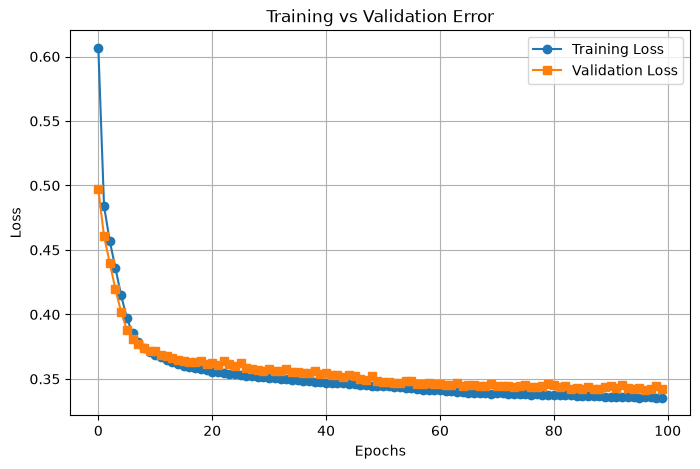

In [36]:
import matplotlib.pyplot as plt
# Plot training vs validation error (loss)
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title("Training vs Validation Error")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

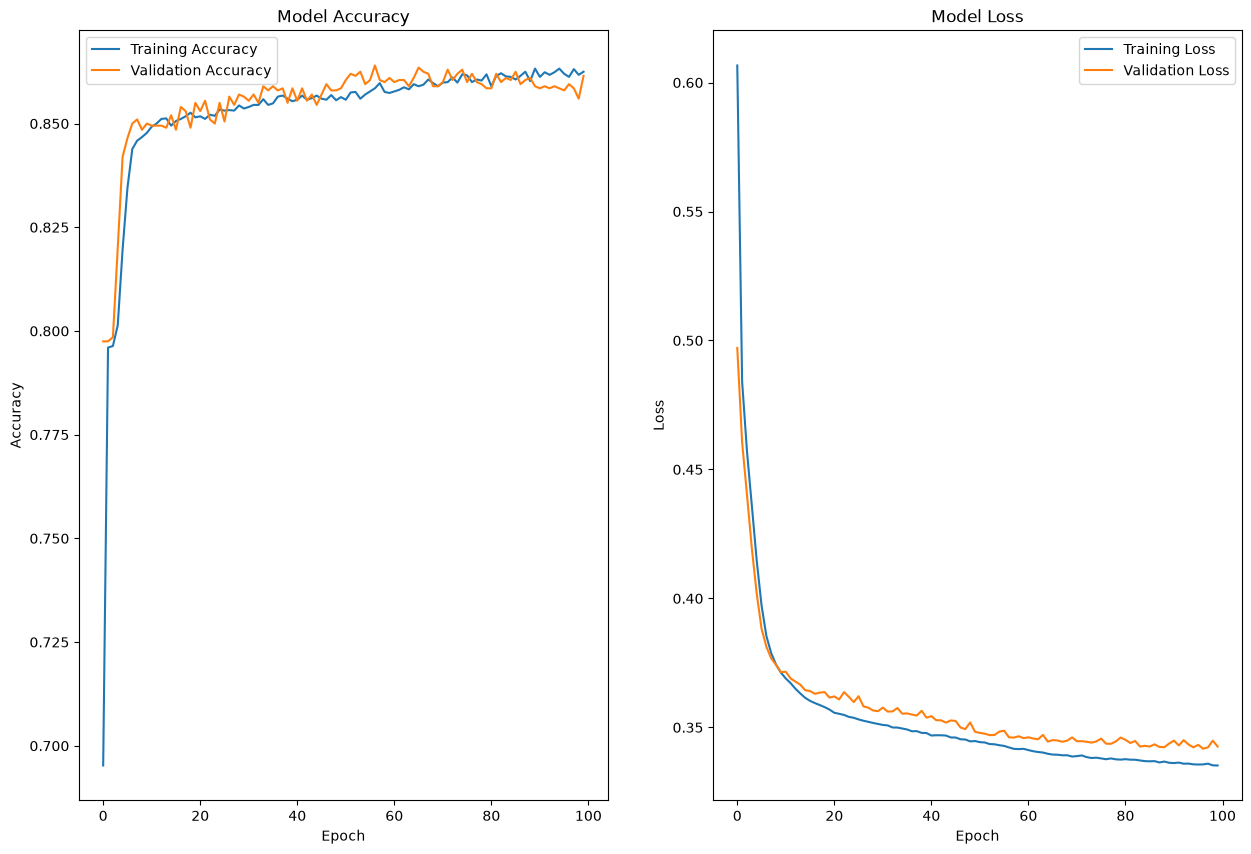

In [37]:
import matplotlib.pyplot as plt
# Plot training history
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
plot_training_history(history)